<a href="https://colab.research.google.com/github/RenukaSiriwardhana/Skin-Cancer-Detection--DermaVision/blob/main/notebooks/Implementation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!pip -q install kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DermaVision/kaggle/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured...")

Kaggle API configured...


In [24]:
import os

DRIVE_ZIP_PATH = "/content/drive/MyDrive/DermaVision/dataset_cache/ham10000-split-and-augmented.zip"
EXTRACT_PATH = "/content/ham10000_dataset"

os.makedirs("/content/drive/MyDrive/DermaVision/dataset_cache", exist_ok=True)

if not os.path.exists(DRIVE_ZIP_PATH):
    print("Downloading dataset from Kaggle (one time only)...")
    !kaggle datasets download -d ahefatresearch/ham10000-split-and-augmented -p /content --force
    !cp /content/ham10000-split-and-augmented.zip "{DRIVE_ZIP_PATH}"
    print("Dataset zip saved to Drive ")
else:
    print("Dataset already exists in Drive (Skipping download)")

Dataset already exists in Drive (Skipping download)


In [25]:
import zipfile
import os

DRIVE_ZIP_PATH = "/content/drive/MyDrive/DermaVision/dataset_cache/ham10000-split-and-augmented.zip"
EXTRACT_PATH = "/content/ham10000_dataset"

# Extract dataset if not already extracted
if not os.path.exists(EXTRACT_PATH):
    print("Extracting dataset...")

    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Extraction completed")
else:
    print("Dataset already extracted")

Dataset already extracted


In [26]:
import os

print(os.listdir("/content/ham10000_dataset"))

['val_dir', 'test_dir', 'train_dir']


In [27]:
train_dir = "/content/ham10000_dataset/val_dir"
val_dir = "/content/ham10000_dataset/train_dir"
test_dir = "/content/ham10000_dataset/test_dir"

In [28]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'ham10000_dataset', 'ham10000-split-and-augmented.zip', 'sample_data']


In [29]:
import os
print(os.listdir("/content/ham10000_dataset"))

['val_dir', 'test_dir', 'train_dir']


In [30]:
import os

train_dir = "/content/ham10000_dataset/train_dir"
val_dir = "/content/ham10000_dataset/val_dir"
test_dir = "/content/ham10000_dataset/test_dir"

def count_images(directory):

    class_counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    return class_counts


print("Training Data Distribution")
print(count_images(train_dir))

print("\nValidation Data Distribution")
print(count_images(val_dir))

print("\nTesting Data Distribution")
print(count_images(test_dir))

Training Data Distribution
{'bkl': 7944, 'bcc': 7965, 'df': 7377, 'mel': 7932, 'akiec': 7854, 'nv': 8004, 'vasc': 7706}

Validation Data Distribution
{'bkl': 66, 'bcc': 26, 'df': 6, 'mel': 34, 'akiec': 23, 'nv': 662, 'vasc': 10}

Testing Data Distribution
{'bkl': 66, 'bcc': 27, 'df': 6, 'mel': 35, 'akiec': 22, 'nv': 663, 'vasc': 9}


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "/content/ham10000_dataset/train_dir"
val_dir = "/content/ham10000_dataset/val_dir"
test_dir = "/content/ham10000_dataset/test_dir"

In [32]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & test preprocessing
test_datagen = ImageDataGenerator(rescale=1./255)

In [33]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Preprocessing completed successfully")

Found 54782 images belonging to 7 classes.
Found 827 images belonging to 7 classes.
Found 828 images belonging to 7 classes.
Preprocessing completed successfully


In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

In [35]:
# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [36]:
# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(7, activation='softmax')(x)

In [37]:
# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [38]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [39]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [40]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [41]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)
print("Training completed")

Epoch 1/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 717s 412ms/step - accuracy: 0.4063 - loss: 1.7723 - val_accuracy: 0.8259 - val_loss: 0.5740 - learning_rate: 1.0000e-04
Epoch 2/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 688s 402ms/step - accuracy: 0.5784 - loss: 1.1451 - val_accuracy: 0.8283 - val_loss: 0.5373 - learning_rate: 1.0000e-04
Epoch 3/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 699s 409ms/step - accuracy: 0.6204 - loss: 1.0159 - val_accuracy: 0.8271 - val_loss: 0.5413 - learning_rate: 1.0000e-04
Epoch 4/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 716s 418ms/step - accuracy: 0.6431 - loss: 0.9523 - val_accuracy: 0.8404 - val_loss: 0.5243 - learning_rate: 1.0000e-04
Epoch 5/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 688s 402ms/step - accuracy: 0.6639 - loss: 0.9023 - val_accuracy: 0.8452 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 6/20
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 688s 402ms/step - accuracy: 0.6744 - loss: 0.8767 - val_accuracy: 0.8452 - val_loss: 0.5176 - learning_rate: 1.0000e-04
Epoch 7/20
1712/1712 ━━━━━━━

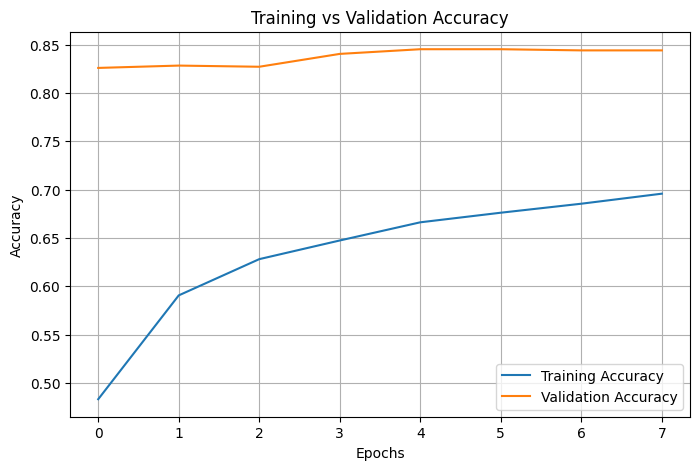

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

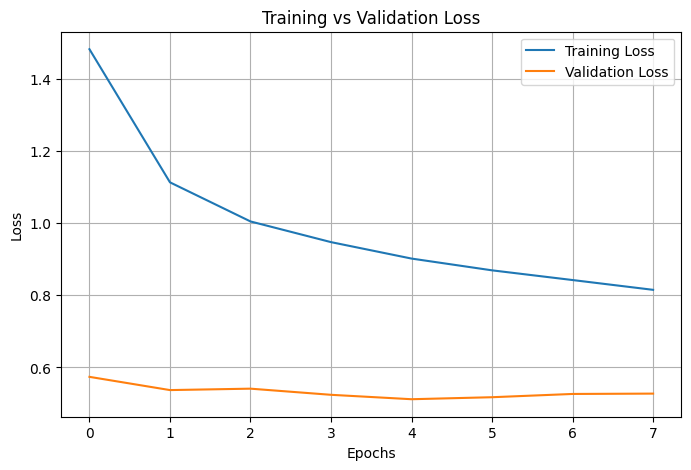

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [42]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

print("Final Test Results")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Final Test Results
Test Accuracy: 0.8429951667785645
Test Loss: 0.5006917119026184


In [44]:
y_pred_probabilities = model.predict(test_generator)

y_pred = np.argmax(y_pred_probabilities, axis=1)

y_test_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 393ms/step


In [45]:
report = classification_report(
    y_test_labels,
    y_pred,
    target_names=class_names
)

print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

       akiec       0.78      0.32      0.45        22
         bcc       0.54      0.52      0.53        27
         bkl       0.37      0.23      0.28        66
          df       0.00      0.00      0.00         6
         mel       0.48      0.31      0.38        35
          nv       0.90      0.97      0.93       663
        vasc       0.80      0.89      0.84         9

    accuracy                           0.84       828
   macro avg       0.55      0.46      0.49       828
weighted avg       0.81      0.84      0.82       828



In [46]:
cm = confusion_matrix(y_test_labels, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  7   3   5   1   0   5   1]
 [  0  14   1   0   3   9   0]
 [  0   6  15   0   4  41   0]
 [  0   0   0   0   0   6   0]
 [  2   1   7   0  11  13   1]
 [  0   2  13   0   5 643   0]
 [  0   0   0   0   0   1   8]]


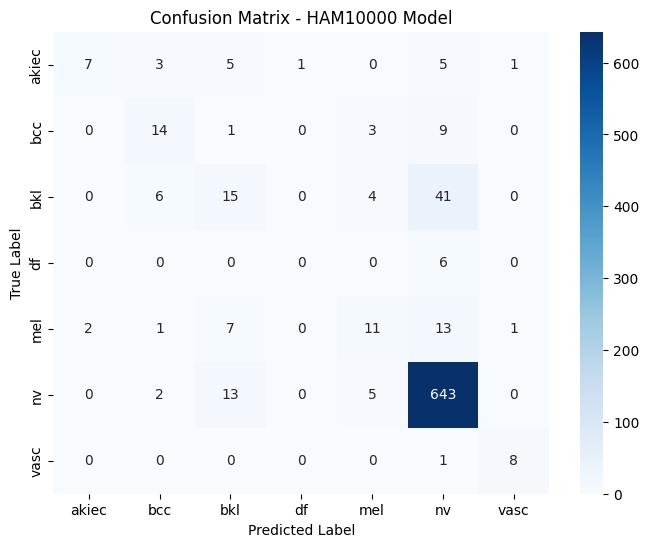

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - HAM10000 Model")

plt.show()

In [50]:
misclassified = np.where(y_test_labels != y_pred)[0]

print("Total Misclassified Images:", len(misclassified))

Total Misclassified Images: 130


In [51]:
os.makedirs("models", exist_ok=True)

model_path = "models/model_v1.h5"

model.save(model_path)

print("Model saved at:", model_path)

Model saved at: models/model_v1.h5
